In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pickle

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import plot_binned_median_map, _nice_step, _grid_step, bin_edges_fd, binned_median, plot_region_map, add_region_column


In [2]:
# Field Data
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_eddies = add_region_column(
    df_eddies,
    X_grid, Y_grid,
    lon_rho, lat_rho,
    h, mask_rho
)
df_AE = df_eddies[df_eddies.Cyc=='AE'].copy()
df_CE = df_eddies[df_eddies.Cyc=='CE'].copy()

df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_ameda = df_ameda[df_ameda.Age>21]
df_ameda = add_region_column(
    df_ameda,
    X_grid, Y_grid,
    lon_rho, lat_rho,
    h, mask_rho
)


(array([2.6510e+03, 7.1320e+03, 9.9850e+03, 1.1718e+04, 1.1719e+04,
        1.1296e+04, 1.0309e+04, 9.1580e+03, 7.7780e+03, 6.4420e+03,
        5.5020e+03, 4.7080e+03, 3.7670e+03, 3.1750e+03, 2.7010e+03,
        2.2080e+03, 1.8510e+03, 1.6140e+03, 1.2530e+03, 1.0730e+03,
        8.9100e+02, 7.5300e+02, 7.1000e+02, 5.3100e+02, 4.8800e+02,
        4.1200e+02, 3.1000e+02, 2.7800e+02, 2.6700e+02, 2.1100e+02,
        2.0600e+02, 1.6000e+02, 1.7100e+02, 1.2000e+02, 1.2100e+02,
        1.1100e+02, 5.8000e+01, 4.9000e+01, 4.7000e+01, 3.3000e+01,
        3.8000e+01, 2.8000e+01, 3.2000e+01, 1.9000e+01, 2.5000e+01,
        1.6000e+01, 1.8000e+01, 8.0000e+00, 1.6000e+01, 1.6000e+01,
        8.0000e+00, 9.0000e+00, 5.0000e+00, 1.0000e+01, 8.0000e+00,
        4.0000e+00, 4.0000e+00, 8.0000e+00, 6.0000e+00, 4.0000e+00,
        2.0000e+00, 4.0000e+00, 2.0000e+00, 5.0000e+00, 3.0000e+00,
        2.0000e+00, 1.0000e+00, 2.0000e+00, 4.0000e+00, 1.0000e+00,
        3.0000e+00, 1.0000e+00, 7.0000e+00, 2.00

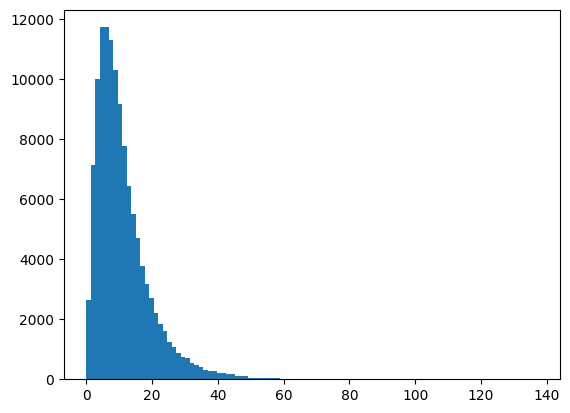

In [4]:
x_km_jump = df_eddies.groupby('Eddy').xc.diff()
y_km_jump = df_eddies.groupby('Eddy').yc.diff()
df_eddies['km_jump'] = np.hypot(x_km_jump, y_km_jump)
plt.hist(df_eddies['km_jump'], bins=100)
    

In [5]:
print(f'No. of Eddies {len(df_eddies.Eddy.unique())}, No. of Eddy-Days {len(df_eddies)}')
print(f'No. of AEs {len(df_AE.Eddy.unique())}, No. of AE-Days {len(df_AE)}')
print(f'No. of CEs {len(df_CE.Eddy.unique())}, No. of CE-Days {len(df_CE)}')


No. of Eddies 2929, No. of Eddy-Days 125226
No. of AEs 1414, No. of AE-Days 63831
No. of CEs 1515, No. of CE-Days 61395


In [6]:
print('Profiles used for tilt')
print(f'No. of Eddy-Days {len(df_eddies)-6*len(df_eddies.Eddy.unique())}')
print(f'No. of AE-Days {len(df_AE)-6*len(df_AE.Eddy.unique())}')
print(f'No. of CE-Days {len(df_CE)-6*len(df_CE.Eddy.unique())}')


Profiles used for tilt
No. of Eddy-Days 107652
No. of AE-Days 55347
No. of CE-Days 52305


In [7]:
print(f'Oldest AE was {df_AE.Age.max()}')
print(f'Oldest CE was {df_CE.Age.max()}')


Oldest AE was 462
Oldest CE was 204


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


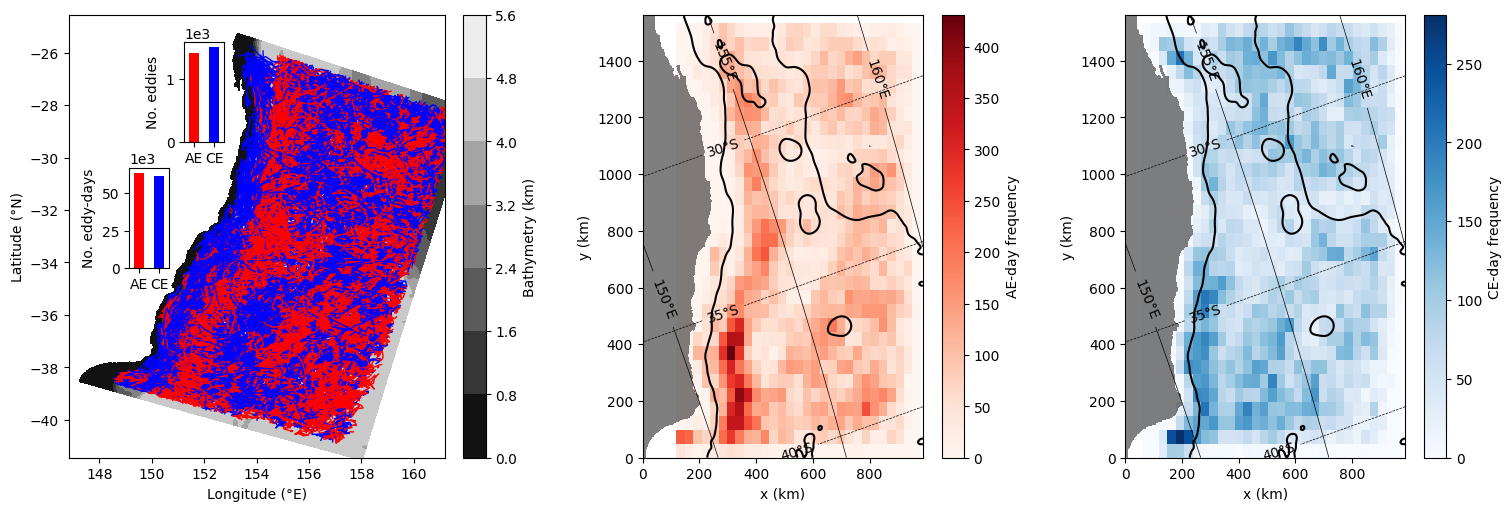

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# --- Panel 1: Map with eddy tracks and insets ---
ax = axs[0]
cs = ax.contourf(lon_rho, lat_rho, np.where(mask_rho, h/1000, np.nan), cmap='grey')
fig.colorbar(cs, ax=ax, label='Bathymetry (km)')

for eddy in df_eddies.Eddy.unique():
    d = df_eddies[df_eddies.Eddy == eddy]
    # ax.plot(d.Lon, d.Lat, lw=1, alpha=1)
    cyc = d.iloc[0].Cyc
    ax.plot(d.lon, d.lat, color='r' if cyc=='AE' else 'b', lw=1, alpha=1)

ax.axis('equal')
ax.set_xlim(148, 160)
ax.set_ylim(-40, -26)
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')

# Inset 1: Eddy counts
df_unique = df_eddies[['Eddy', 'Cyc']].drop_duplicates()
in_ax1 = inset_axes(ax, width=.4, height=1, loc='center',
                   bbox_to_anchor=(152, -27.5, 0, 0),
                   bbox_transform=ax.transData, borderpad=0)
counts = df_unique['Cyc'].value_counts().reindex(['AE','CE']).fillna(0)
counts.plot(kind='bar', color=['r','b'], ax=in_ax1)
in_ax1.set_xlabel('')
in_ax1.set_ylabel('No. eddies')
in_ax1.tick_params(axis='x', rotation=0)
in_ax1.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
in_ax1.set_facecolor('none')

# Inset 2: Eddy-day counts
in_ax2 = inset_axes(ax, width=.4, height=1, loc='center',
                   bbox_to_anchor=(149.9, -32.3, 0, 0),
                   bbox_transform=ax.transData, borderpad=0)
counts = df_eddies['Cyc'].value_counts().reindex(['AE','CE']).fillna(0)
counts.plot(kind='bar', color=['r','b'], ax=in_ax2)
in_ax2.set_xlabel('')
in_ax2.set_ylabel('No. eddy-days')
in_ax2.tick_params(axis='x', rotation=0)
in_ax2.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
in_ax2.set_facecolor('none')

# --- Panel 2 & 3: Eddy-day distributions ---
for d, subset in enumerate([df_eddies[df_eddies.Cyc == 'AE'], df_eddies[df_eddies.Cyc == 'CE']]):
    eddy_x = subset.xc.to_numpy()
    eddy_y = subset.yc.to_numpy()

    x_edges = bin_edges_fd(eddy_x, X_grid, rule='fd')  # or rule='scott'/'fd'
    y_edges = bin_edges_fd(eddy_y, Y_grid, rule='fd')
    # print(f'x-bin size: {np.mean(np.diff(x_edges))}')
    # print(f'y-bin size: {np.mean(np.diff(y_edges))}')

    H, _, _ = np.histogram2d(eddy_y, eddy_x, bins=[y_edges, x_edges])

    pcm = axs[d+1].pcolormesh(x_edges, y_edges, H, cmap='Reds' if d==0 else 'Blues')
    fig.colorbar(pcm, ax=axs[d+1], label='AE-day frequency' if d==0 else 'CE-day frequency')

    axs[d+1].contourf(X_grid, Y_grid, np.where(mask_rho == 0, 1, np.nan),
                      levels=[0.5, 1.5], colors=['k'], alpha=.5)

    c1 = axs[d+1].contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
    axs[d+1].clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = axs[d+1].contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
    axs[d+1].clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
    
    axs[d+1].contour(X_grid, Y_grid, h, levels=[4000], colors='k')

    axs[d+1].set_xlabel('x (km)')
    axs[d+1].set_ylabel('y (km)')
    axs[d+1].set_aspect('equal')
    
# plt.tight_layout()
plt.show()


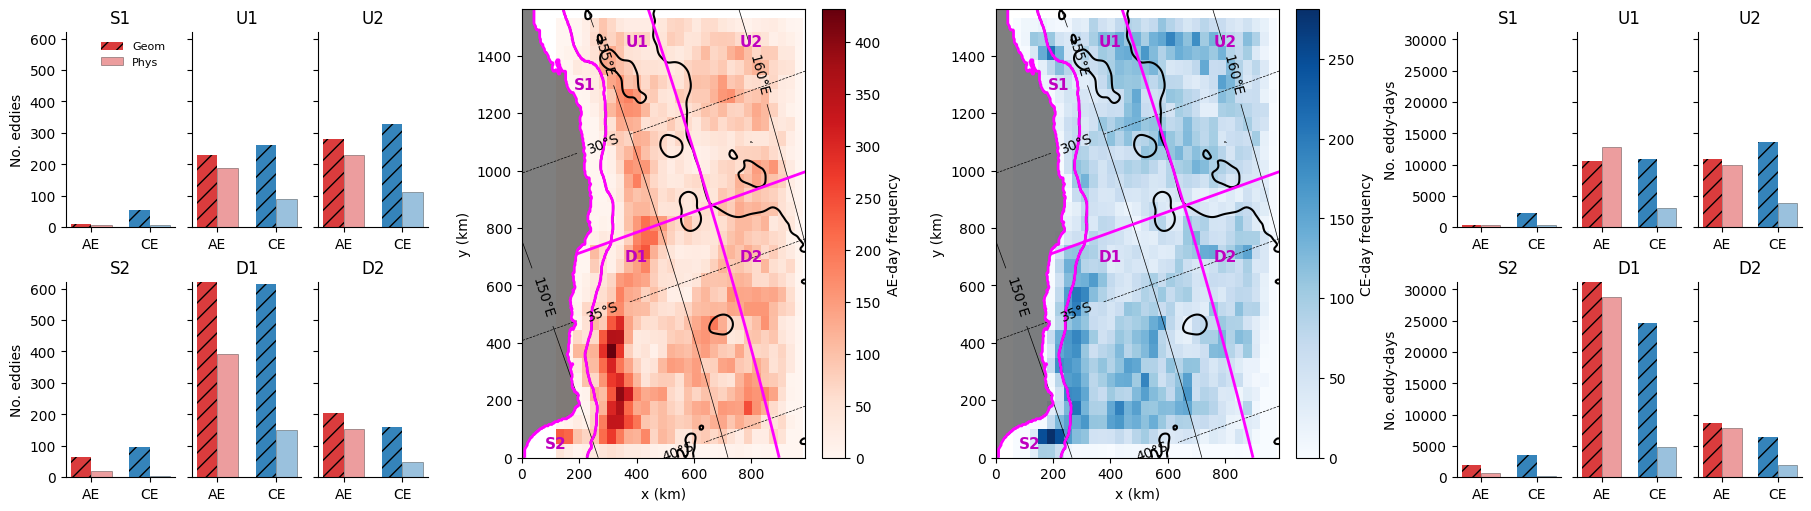

In [9]:
def eddy_majority_region_counts(df, region_order):
    """
    Assign each eddy to the region where it spends the most eddy-days,
    then count eddies by majority region and Cyc.
    """
    eddy_region = (
        df[df.Region.isin(region_order)]
        .groupby(['Eddy', 'Cyc', 'Region'])
        .size()
        .reset_index(name='days')
        .sort_values(['Eddy', 'Cyc', 'days'], ascending=[True, True, False])
        .drop_duplicates(['Eddy', 'Cyc'])
    )

    return (
        eddy_region
        .groupby(['Region', 'Cyc'])
        .size()
        .unstack('Cyc')
        .reindex(region_order)
        .reindex(columns=['AE', 'CE'])
        .fillna(0)
    )


fig = plt.figure(figsize=(18, 5), constrained_layout=True)

gs = fig.add_gridspec(
    1, 4,
    width_ratios=[1.25, 1, 1, 1.25]
    # width_ratios=[1.25, 1.25, 1, 1]
)

region_order = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']


# gs_eddies = gs[0].subgridspec(2, 3)
# gs_days   = gs[1].subgridspec(2, 3)
# axs_map   = [fig.add_subplot(gs[2]), fig.add_subplot(gs[3])]

gs_eddies = gs[0].subgridspec(2, 3)
axs_map = [
    fig.add_subplot(gs[1]),
    fig.add_subplot(gs[2])
]
gs_days = gs[3].subgridspec(2, 3)


# ==================================================
# Panel 1: Number of eddies by majority region
# ==================================================
# gs_eddies = gs[0].subgridspec(2, 3)

d_eddy_counts = eddy_majority_region_counts(df_eddies, region_order)
a_eddy_counts = eddy_majority_region_counts(df_ameda, region_order)

max_eddies = max(
    d_eddy_counts.max().max(),
    a_eddy_counts.max().max()
)

for i, region in enumerate(region_order):

    ax = fig.add_subplot(gs_eddies[i // 3, i % 3])

    d = d_eddy_counts.loc[region].reindex(['AE', 'CE']).fillna(0)
    a = a_eddy_counts.loc[region].reindex(['AE', 'CE']).fillna(0)

    x = np.arange(2)
    w = 0.35

    ax.bar(
        x - w/2,
        d.values,
        width=w,
        color=['tab:red', 'tab:blue'],
        alpha=0.9,
        hatch='//',
        label='Geom'
    )

    ax.bar(
        x + w/2,
        a.values,
        width=w,
        color=['tab:red', 'tab:blue'],
        alpha=0.45,
        edgecolor='k',
        linewidth=0.5,
        label='Phys'
    )

    ax.set_title(region)
    ax.set_xticks(x)
    ax.set_xticklabels(['AE', 'CE'])
    ax.set_ylim(0, max_eddies)

    if i in [0, 3]:
        ax.set_ylabel('No. eddies')
    else:
        ax.set_yticklabels([])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if i == 0:
        ax.legend(frameon=False, fontsize=8)

# ==================================================
# Panel 2: Number of eddy-days by region
# ==================================================
# gs_days = gs[1].subgridspec(2, 3)

max_eddy_days = max(
    df_eddies.groupby(['Region', 'Cyc']).size().max(),
    df_ameda.groupby(['Region', 'Cyc']).size().max()
)

for i, region in enumerate(region_order):

    ax = fig.add_subplot(gs_days[i // 3, i % 3])

    d = (
        df_eddies[df_eddies.Region == region]
        .groupby('Cyc')
        .size()
        .reindex(['AE', 'CE'])
        .fillna(0)
    )

    a = (
        df_ameda[df_ameda.Region == region]
        .groupby('Cyc')
        .size()
        .reindex(['AE', 'CE'])
        .fillna(0)
    )

    x = np.arange(2)
    w = 0.35

    ax.bar(
        x - w/2,
        d.values,
        width=w,
        color=['tab:red', 'tab:blue'],
        alpha=0.9,
        hatch='//',
        label='Geom'
    )

    ax.bar(
        x + w/2,
        a.values,
        width=w,
        color=['tab:red', 'tab:blue'],
        alpha=0.45,
        edgecolor='k',
        linewidth=0.5,
        label='Phys'
    )

    ax.set_title(region)
    ax.set_xticks(x)
    ax.set_xticklabels(['AE', 'CE'])
    ax.set_ylim(0, max_eddy_days)

    if i in [0, 3]:
        ax.set_ylabel('No. eddy-days')
    else:
        ax.set_yticklabels([])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ==================================================
# Panels 3 and 4: Eddy-day spatial distributions
# ==================================================
# axs_map = [
#     fig.add_subplot(gs[2]),
#     fig.add_subplot(gs[3])
# ]

for d, subset in enumerate([
    df_eddies[df_eddies.Cyc == 'AE'],
    df_eddies[df_eddies.Cyc == 'CE']
]):

    eddy_x = subset.xc.to_numpy()
    eddy_y = subset.yc.to_numpy()

    x_edges = bin_edges_fd(eddy_x, X_grid, rule='fd')
    y_edges = bin_edges_fd(eddy_y, Y_grid, rule='fd')

    H, _, _ = np.histogram2d(eddy_y, eddy_x, bins=[y_edges, x_edges])

    pcm = axs_map[d].pcolormesh(
        x_edges,
        y_edges,
        H,
        cmap='Reds' if d == 0 else 'Blues'
    )

    fig.colorbar(
        pcm,
        ax=axs_map[d],
        label='AE-day frequency' if d == 0 else 'CE-day frequency'
    )

    axs_map[d].contourf(
        X_grid, Y_grid,
        np.where(mask_rho == 0, 1, np.nan),
        levels=[0.5, 1.5],
        colors=['k'],
        alpha=0.5
    )

    c1 = axs_map[d].contour(
        X_grid, Y_grid,
        lat_rho,
        levels=[-40, -35, -30, -25],
        colors='k',
        linewidths=0.5
    )
    axs_map[d].clabel(
        c1,
        fmt=lambda v: f"{np.abs(v):.0f}°S",
        inline=True,
        colors='k'
    )

    c2 = axs_map[d].contour(
        X_grid, Y_grid,
        lon_rho,
        levels=[150, 155, 160],
        colors='k',
        linewidths=0.5
    )
    axs_map[d].clabel(
        c2,
        fmt=lambda v: f"{v:.0f}°E",
        inline=True,
        colors='k'
    )

    axs_map[d].contour(
        X_grid, Y_grid, h,
        levels=[4000],
        colors='k'
    )

    plot_region_map(
        axs_map[d],
        X_grid,
        Y_grid,
        lon_rho,
        lat_rho,
        h,
        mask_rho,
        levels_lat,
        levels_lon,
        lon_split=157,
        lat_split=-33,
        title=None,
        borders_only=True
    )

    axs_map[d].set_xlabel('x (km)')
    axs_map[d].set_ylabel('y (km)')
    axs_map[d].set_aspect('equal')

plt.show()



Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


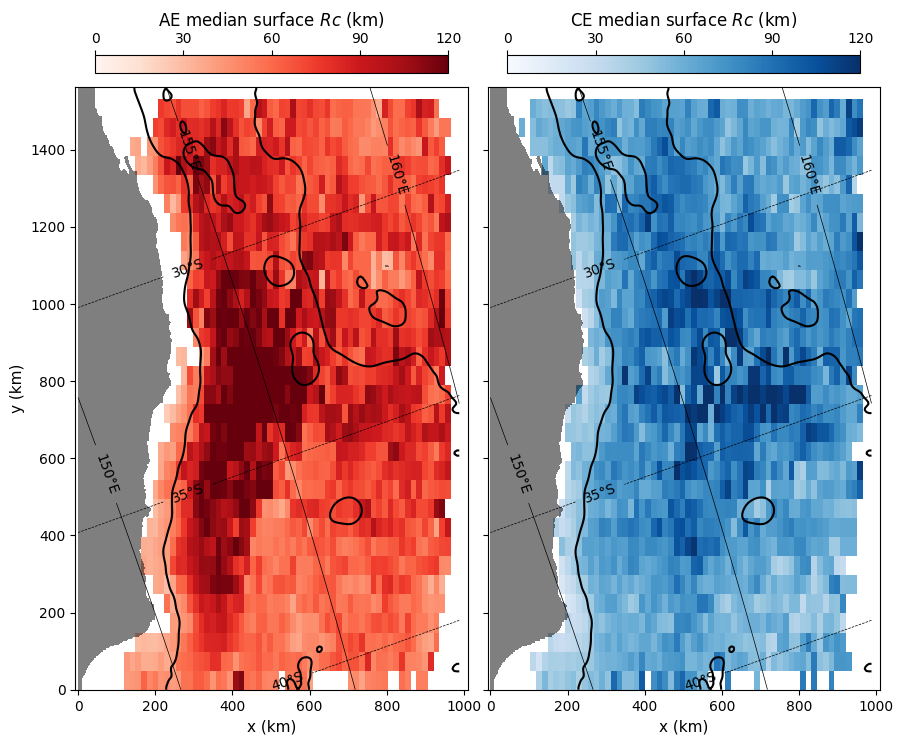

In [10]:
fig, axs = plot_binned_median_map(df_eddies, metric='Rc', vmin=0, vmax=120)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


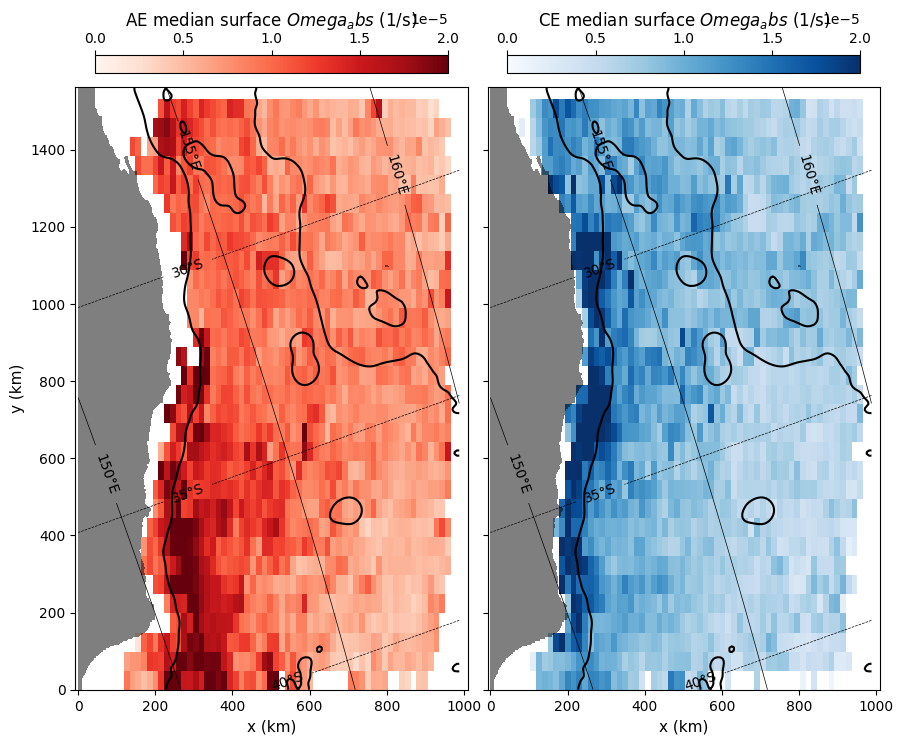

In [11]:
df_eddies['Omega_abs'] = df_eddies.Omega.abs()
fig, axs = plot_binned_median_map(df_eddies, metric='Omega_abs', vmin=0, vmax=2e-5, units='1/s')


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


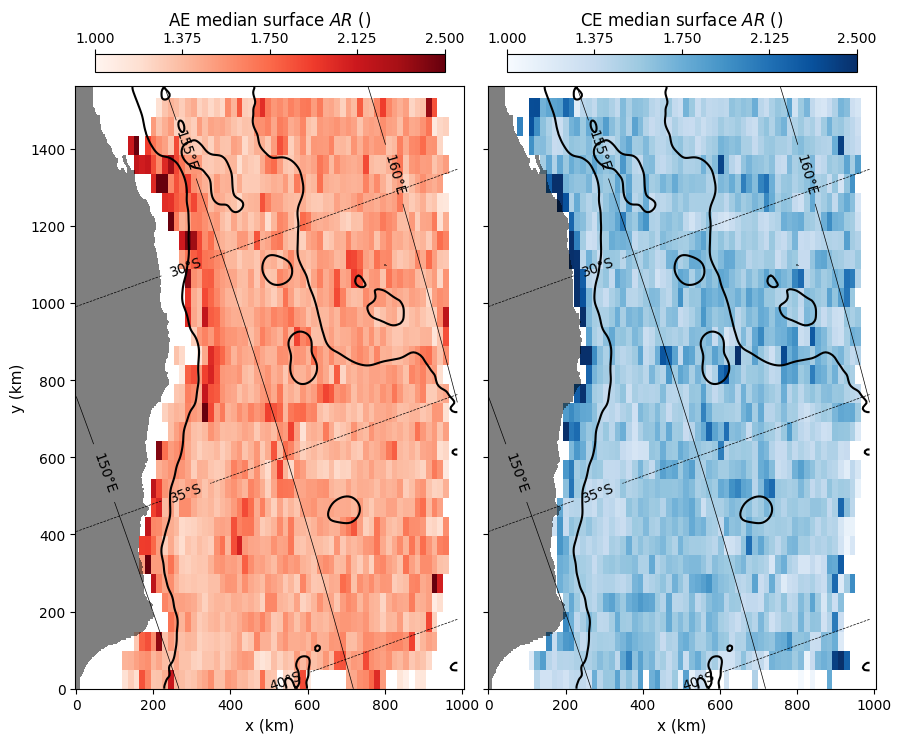

In [12]:
fig, axs = plot_binned_median_map(df_eddies, metric='AR', vmin=1, vmax=2.5, units='')


In [13]:
with open('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl', 'rb') as f:
    dic_vert = pickle.load(f)


In [14]:
depths = []
for k in range(len(df_eddies)):
    data = df_eddies.iloc[k]
    df = dic_vert[f'Eddy{data.Eddy}'][f'Day{data.Day}']
    if len(df):
        depths.append(np.abs(df.iloc[-1].Depth)/1e3)
    else:
        depths.append(0)
df_eddies['zmax'] = depths
zmax_idx = [np.argmin(np.abs(np.abs(z_r[150,150,:])/1e3 - z)) for z in df_eddies.zmax]
df_eddies['zmax_idx'] = zmax_idx


In [15]:
eddy_props = []
for eddy in df_eddies.Eddy.unique():
    df = df_eddies[df_eddies.Eddy==eddy].copy()
    eddy_props.extend(np.array(np.hypot(df.xc.diff(), df.yc.diff()) * 0.011574))
df_eddies['EddyProp'] = eddy_props


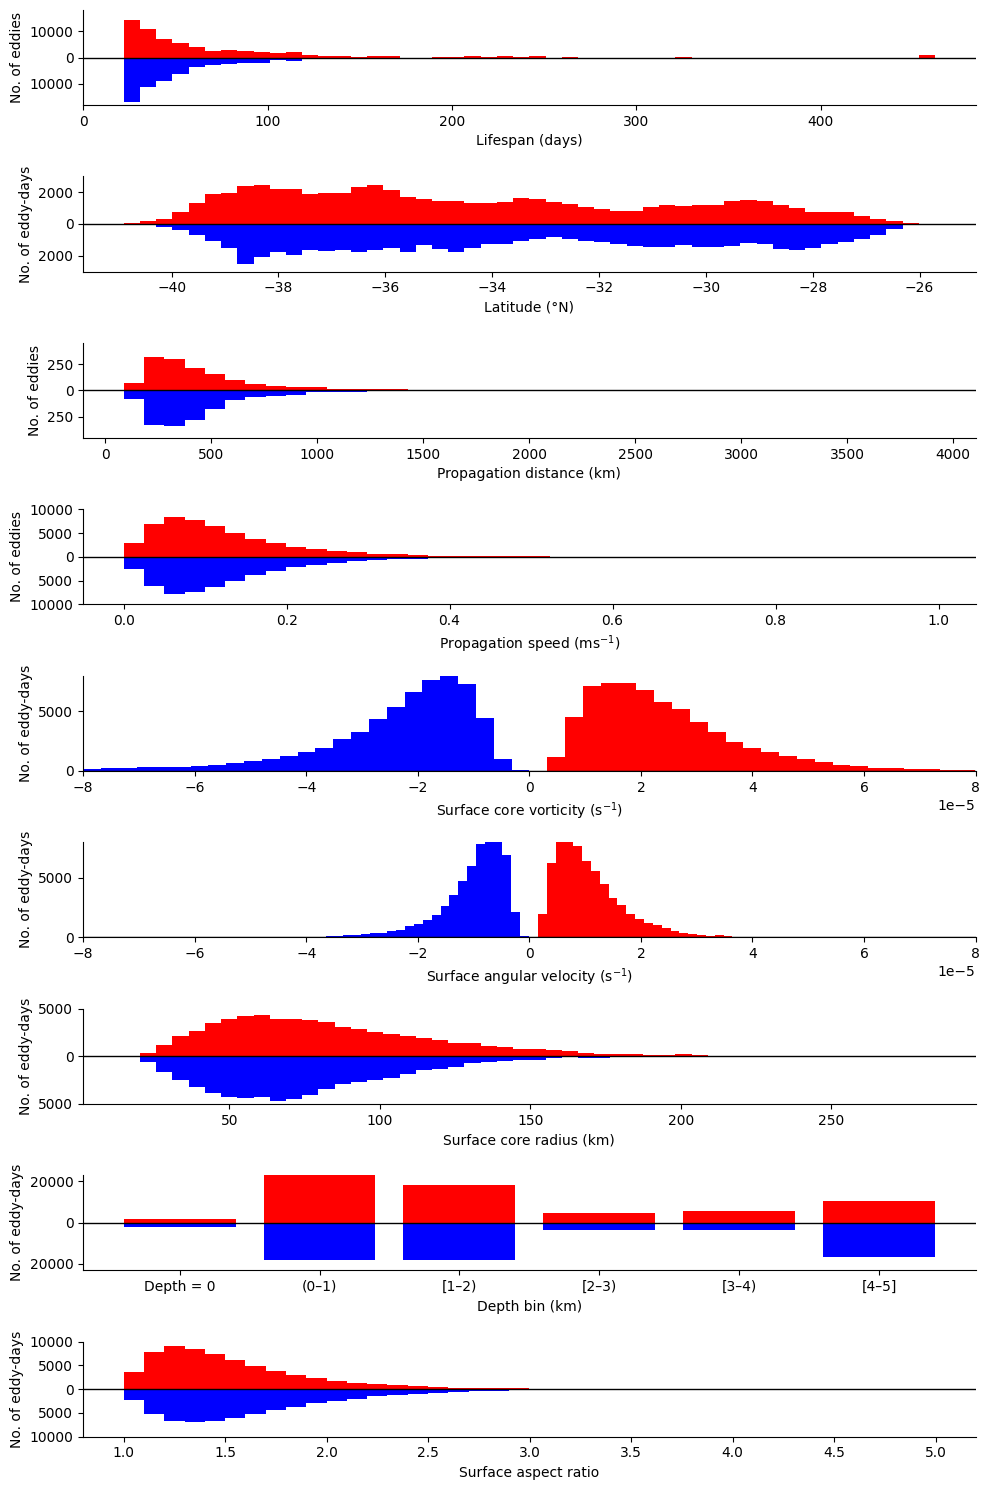

In [16]:
fig, axs = plt.subplots(9, 1, figsize=(10, 15))

def clean(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return a[np.isfinite(a)], b[np.isfinite(b)]

def shared_bins(a, b, method='fd', min_bins=12, max_bins=40):
    a, b = clean(a, b)
    all_vals = np.concatenate([a, b])
    
    if all_vals.size == 0:
        return np.linspace(0, 1, min_bins + 1)
    if np.all(all_vals == all_vals[0]):
        return np.linspace(all_vals[0] - 0.5, all_vals[0] + 0.5, min_bins + 1)

    edges = np.histogram_bin_edges(all_vals, bins=method)
    n_bins = len(edges) - 1

    if n_bins < min_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), min_bins + 1)
    elif n_bins > max_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), max_bins + 1)

    return edges

def mirrored_hist(ax, ae, ce, bins, xlabel, ylabel, ylim=None, xlim=None, mirror_flag=True):
    ae, ce = clean(ae, ce)

    ax.hist(ae, bins=bins, color='r')
    counts, edges = np.histogram(ce, bins=bins)
    if mirror_flag:
        ax.bar(edges[:-1], -counts, width=np.diff(edges), color='b', align='edge')
    else:
        ax.bar(edges[:-1], counts, width=np.diff(edges), color='b', align='edge')

    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([abs(int(t)) for t in ax.get_yticks()])

    if ylim is not None:
        ax.set_ylim(ylim)
    if xlim is not None:
        ax.set_xlim(xlim)

# --- Plot 0: Age ---
ax = axs[0]
ae = df_eddies.loc[df_eddies.Cyc == 'AE', 'Age']
ce = df_eddies.loc[df_eddies.Cyc == 'CE', 'Age']
bins0 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    ax, ae, ce, bins0,
    'Lifespan (days)', 'No. of eddies',
    ylim=(-18000, 18000)
)

# --- Plot 1: Lat ---
ax = axs[1]
ae = df_eddies.loc[df_eddies.Cyc == 'AE', 'lat']
ce = df_eddies.loc[df_eddies.Cyc == 'CE', 'lat']
bins1 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    ax, ae, ce, bins1,
    'Latitude (°N)', 'No. of eddy-days',
    ylim=(-3000, 3000)
)

# --- Plot 2: Propagation Distance ---
ax = axs[2]
eddy_props_AE, eddy_props_CE = [], []
for eddy in df_eddies.Eddy.unique():
    df = df_eddies[df_eddies.Eddy == eddy]
    dist = np.nansum(np.hypot(df.xc.diff(), df.yc.diff()))
    if df.iloc[0].Cyc == 'AE':
        eddy_props_AE.append(dist)
    else:
        eddy_props_CE.append(dist)

bins2 = shared_bins(eddy_props_AE, eddy_props_CE, method='fd', min_bins=15, max_bins=40)
mirrored_hist(
    ax, eddy_props_AE, eddy_props_CE, bins2,
    'Propagation distance (km)', 'No. of eddies',
    ylim=(-450, 450)
)

# --- Plot 3: Propagation Speed ---
ax = axs[3]
dfAE = df_eddies[df_eddies.Cyc == 'AE'].copy().dropna()
dfAE = dfAE[dfAE.EddyProp <= 1]
dfCE = df_eddies[df_eddies.Cyc == 'CE'].copy().dropna()
dfCE = dfCE[dfCE.EddyProp <= 1]

bins3 = shared_bins(dfAE.EddyProp, dfCE.EddyProp, method='fd', min_bins=15, max_bins=40)
mirrored_hist(
    ax, dfAE.EddyProp, dfCE.EddyProp, bins3,
    r'Propagation speed (ms$^{-1}$)', 'No. of eddies',
    ylim=(-10000, 10000)
)

# --- Plot 4: Vorticity ---
ax = axs[4]
df_v = df_eddies[df_eddies.w.abs() <= 8e-5]
ae = df_v.loc[df_v.Cyc == 'AE', 'w']
ce = df_v.loc[df_v.Cyc == 'CE', 'w']
bins4 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    ax, ae, ce, bins4,
    r'Surface core vorticity (s$^{-1}$)', 'No. of eddy-days',
    xlim=(-8e-5, 8e-5),
    mirror_flag=False,
    ylim=(0, 8000)
)

# --- Plot 4: Angular velocity ---
ax = axs[5]
df_v = df_eddies[df_eddies.w.abs() <= 8e-5]
ae = df_v.loc[df_v.Cyc == 'AE', 'Omega']
ce = df_v.loc[df_v.Cyc == 'CE', 'Omega']
bins4 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    ax, ae, ce, bins4,
    r'Surface angular velocity (s$^{-1}$)', 'No. of eddy-days',
    xlim=(-8e-5, 8e-5),
    mirror_flag=False,
    ylim=(0, 8000)
)

# --- Plot 5: Radius ---
ax = axs[6]
ae = df_eddies.loc[df_eddies.Cyc == 'AE', 'Rc']
ce = df_eddies.loc[df_eddies.Cyc == 'CE', 'Rc']
bins5 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    ax, ae, ce, bins5,
    r'Surface core radius (km)', 'No. of eddy-days',
    ylim=(-5000, 5000)
)

# --- Plot 6: Depth ---
ax = axs[7]
bin_int = 1
max_depth_km = 5
edges = np.arange(0, max_depth_km + bin_int, bin_int)

def _fmt(x):
    return f"{x:.0f}" if float(bin_int).is_integer() else f"{x:.1f}"

bin_labels = (
    ["Depth = 0", f"({_fmt(edges[0])}–{_fmt(edges[0] + bin_int)})"]
    + [f"[{_fmt(b)}–{_fmt(b+bin_int)})" for b in edges[1:-1]]
)
bin_labels[-1] = f"[{_fmt(edges[-2])}–{_fmt(edges[-1])}]"

ae_raw = df_eddies.loc[df_eddies.Cyc == 'AE', 'zmax'].dropna().to_numpy()
ce_raw = df_eddies.loc[df_eddies.Cyc == 'CE', 'zmax'].dropna().to_numpy()

ae = ae_raw[(ae_raw >= edges[0]) & (ae_raw <= edges[-1])]
ce = ce_raw[(ce_raw >= edges[0]) & (ce_raw <= edges[-1])]

ae0 = int(np.isclose(ae, 0).sum())
ce0 = int(np.isclose(ce, 0).sum())

ae_nz = ae[~np.isclose(ae, 0)]
ce_nz = ce[~np.isclose(ce, 0)]

ae_counts, _ = np.histogram(ae_nz, bins=edges)
ce_counts, _ = np.histogram(ce_nz, bins=edges)

ae_counts = np.insert(ae_counts, 0, ae0)
ce_counts = np.insert(ce_counts, 0, ce0)

xpos = np.arange(len(bin_labels))
ax.bar(xpos,  ae_counts, color='r')
ax.bar(xpos, -ce_counts, color='b')

ax.axhline(0, color='k', linewidth=1)
m = max(1, int(max(ae_counts.max(), ce_counts.max()) * 1))
ax.set_xticks(xpos)
ax.set_xticklabels(bin_labels, rotation=0, ha='center')
ax.set_xlabel('Depth bin (km)')
ax.set_ylabel('No. of eddy-days')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([abs(int(t)) for t in ax.get_yticks()])
ax.set_ylim(-m, m)

# --- Plot 7: Aspect ratio ---
ax = axs[8]
df_a = df_eddies[df_eddies.AR <= 5]
ae = df_a.loc[df_a.Cyc == 'AE', 'AR']
ce = df_a.loc[df_a.Cyc == 'CE', 'AR']
bins7 = shared_bins(ae, ce, method='fd', min_bins=15, max_bins=40)
mirrored_hist(
    ax, ae, ce, bins7,
    'Surface aspect ratio', 'No. of eddy-days',
    ylim=(-10000, 10000)
)

plt.tight_layout()
plt.show()


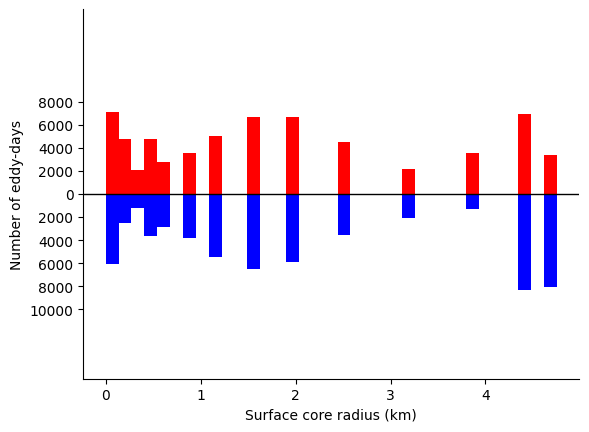

In [17]:
fig, ax = plt.subplots()

# --- Plot 5: Radius ---
df = df_eddies.copy()

ae = df.loc[df.Cyc == 'AE', 'zmax']
ce = df.loc[df.Cyc == 'CE', 'zmax']
bins5 = shared_bins(ae, ce, method='fd', min_bins=20, max_bins=50)
mirrored_hist(
    ax, ae, ce, bins5,
    r'Surface core radius (km)', 'Number of eddy-days',
    ylim=(-16000, 16000)
)


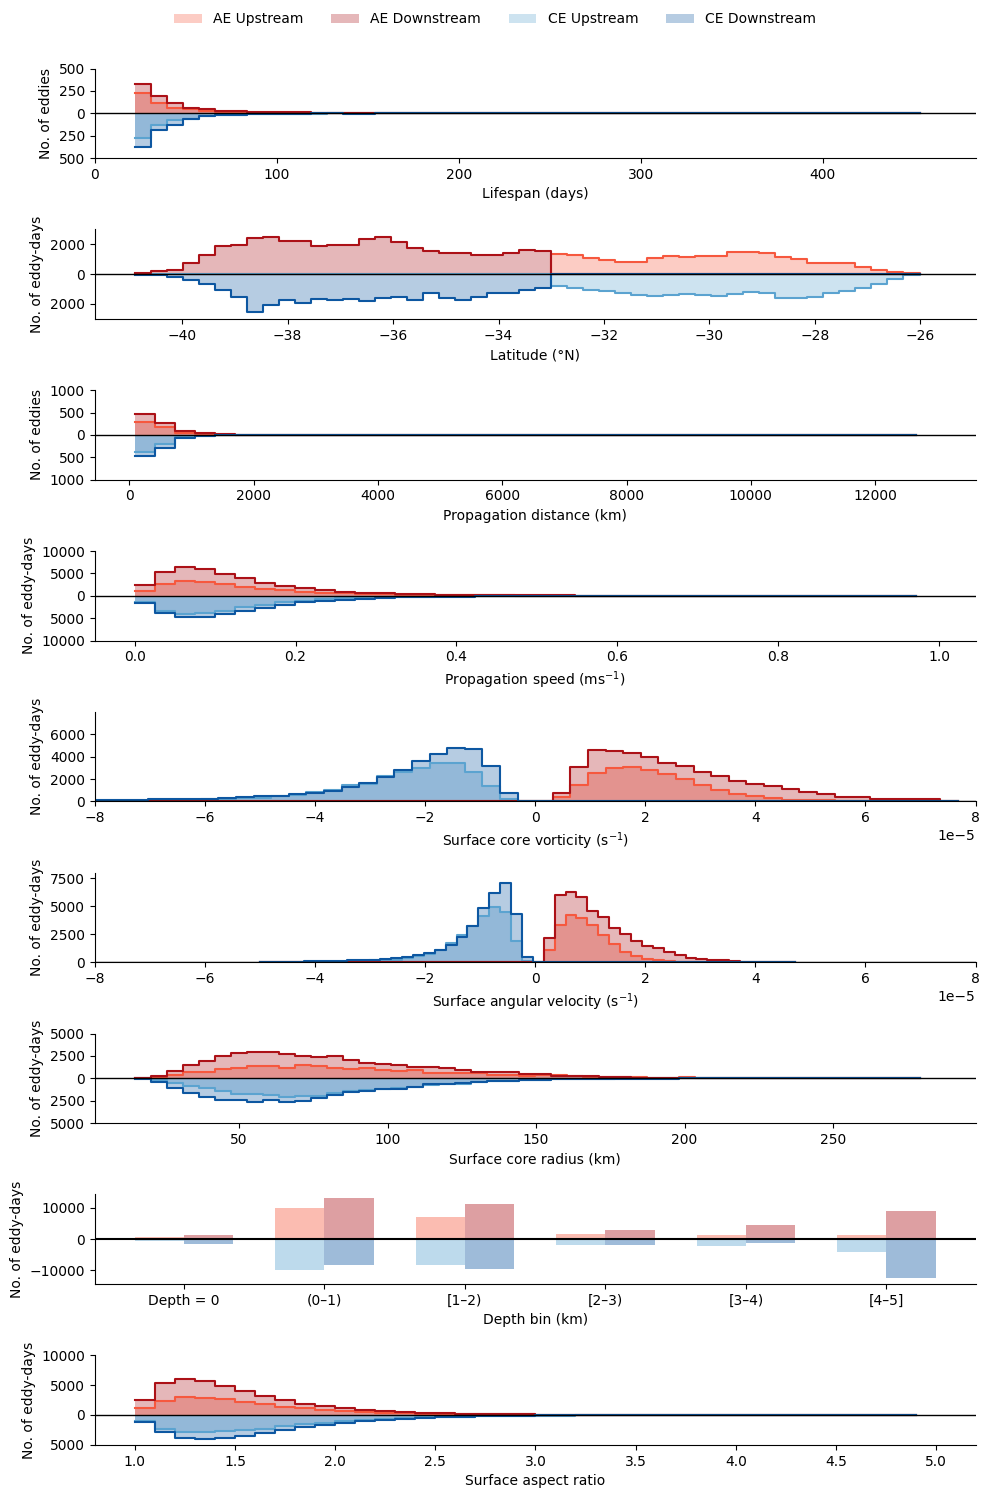

In [18]:
# ==========================================================
# Collapse six regions into upstream/downstream
# ==========================================================

region_group_map = {
    'S1': 'Upstream',
    'U1': 'Upstream',
    'U2': 'Upstream',
    'S2': 'Downstream',
    'D1': 'Downstream',
    'D2': 'Downstream'
}

df_day = df_eddies.copy()
df_day['RegionGroup'] = df_day['Region'].map(region_group_map)


# ==========================================================
# Eddy-level region assignment (>50% lifetime)
# ==========================================================

def assign_dominant_region_group(df, threshold=0.5):

    rows = []

    for eddy, dfe in df.dropna(subset=['Region']).groupby('Eddy'):

        region_group = dfe['Region'].map(region_group_map)

        frac = region_group.value_counts(normalize=True)

        dom_region = frac.index[0]
        dom_frac = frac.iloc[0]

        if dom_frac > threshold:

            rows.append({
                'Eddy': eddy,
                'RegionGroup': dom_region,
                'RegionFrac': dom_frac
            })

    return pd.DataFrame(rows)


def build_eddy_level_df(df, threshold=0.5):

    eddy_region = assign_dominant_region_group(
        df,
        threshold=threshold
    )

    rows = []

    for eddy, dfe in df.groupby('Eddy'):

        dfe = dfe.sort_values('Age')

        rows.append({
            'Eddy': eddy,
            'Cyc': dfe.Cyc.iloc[0],
            'Age': dfe.Age.max(),
            'PropDist': np.nansum(
                np.hypot(
                    dfe.xc.diff(),
                    dfe.yc.diff()
                )
            )
        })

    df_eddy = pd.DataFrame(rows)

    df_eddy = df_eddy.merge(
        eddy_region,
        on='Eddy',
        how='inner'
    )

    return df_eddy


df_eddy = build_eddy_level_df(df_eddies)


# ==========================================================
# Histogram helper
# ==========================================================

def mirrored_hist_regions(
    ax,
    df,
    col,
    bins,
    xlabel,
    ylabel,
    ylim=None,
    xlim=None,
    mirror_flag=True,
    regions=('Upstream', 'Downstream'),
    alpha=0.30,
    median_flag=False
):

    reds = plt.get_cmap('Reds')
    blues = plt.get_cmap('Blues')

    red_cols = {
        'Upstream': reds(0.55),
        'Downstream': reds(0.85),
    }

    blue_cols = {
        'Upstream': blues(0.55),
        'Downstream': blues(0.85),
    }

    for region in regions:

        dfr = df[df.RegionGroup == region]

        ae = clean(
            dfr.loc[dfr.Cyc == 'AE', col]
        )

        ce = clean(
            dfr.loc[dfr.Cyc == 'CE', col]
        )

        # AE
        ax.hist(
            ae,
            bins=bins,
            color=red_cols[region],
            alpha=alpha,
            histtype='stepfilled',
            label=f'AE {region}'
        )

        ae_counts, edges = np.histogram(
            ae,
            bins=bins
        )

        ax.step(
            edges[:-1],
            ae_counts,
            where='post',
            color=red_cols[region],
            linewidth=1.5
        )

        # CE
        ce_counts, edges = np.histogram(
            ce,
            bins=bins
        )

        sign = -1 if mirror_flag else 1

        ax.bar(
            edges[:-1],
            sign * ce_counts,
            width=np.diff(edges),
            color=blue_cols[region],
            alpha=alpha,
            align='edge',
            label=f'CE {region}'
        )

        ax.step(
            edges[:-1],
            sign * ce_counts,
            where='post',
            color=blue_cols[region],
            linewidth=1.5
        )

    # if median_flag:
    
    #     if len(ae):
    #         ax.axvline(
    #             np.nanmedian(ae),
    #             color=red_cols[region],
    #             linewidth=2,
    #             linestyle='--',
    #             alpha=0.9
    #         )
    
    #     if len(ce):
    #         ax.axvline(
    #             np.nanmedian(ce),
    #             color=blue_cols[region],
    #             linewidth=2,
    #             linestyle='--',
    #             alpha=0.9
    #         )

    if median_flag:
    
        for region in regions:
    
            dfr = df[df.RegionGroup == region]
    
            ae = clean(
                dfr.loc[dfr.Cyc == 'AE', col]
            )
    
            ce = clean(
                dfr.loc[dfr.Cyc == 'CE', col]
            )
    
            ls = '--' if region == 'Upstream' else '-'
    
            if len(ae):
                ax.axvline(
                    np.nanmedian(ae),
                    color='red',
                    linestyle=ls,
                    linewidth=2.5,
                    zorder=100
                )
    
            if len(ce):
                ax.axvline(
                    np.nanmedian(ce),
                    color='blue',
                    linestyle=ls,
                    linewidth=2.5,
                    zorder=100
                )

    ax.axhline(0, color='k', linewidth=1)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(
        [abs(int(t)) for t in ax.get_yticks()]
    )

    if ylim is not None:
        ax.set_ylim(ylim)

    if xlim is not None:
        ax.set_xlim(xlim)

def shared_bins_multi(vals, method='fd', min_bins=12, max_bins=40):
    vals = [clean(v) for v in vals]
    vals = [v for v in vals if len(v) > 0]

    if len(vals) == 0:
        return np.linspace(0, 1, min_bins + 1)

    all_vals = np.concatenate(vals)

    if np.all(all_vals == all_vals[0]):
        return np.linspace(all_vals[0] - 0.5, all_vals[0] + 0.5, min_bins + 1)

    edges = np.histogram_bin_edges(all_vals, bins=method)
    n_bins = len(edges) - 1

    if n_bins < min_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), min_bins + 1)
    elif n_bins > max_bins:
        edges = np.linspace(all_vals.min(), all_vals.max(), max_bins + 1)

    return edges

def clean(a):
    a = np.asarray(a, dtype=float)
    return a[np.isfinite(a)]

# ==========================================================
# Depth plot helper colours
# ==========================================================

regions = ['Upstream', 'Downstream']

red_cols = {
    'Upstream': plt.cm.Reds(0.55),
    'Downstream': plt.cm.Reds(0.85)
}

blue_cols = {
    'Upstream': plt.cm.Blues(0.55),
    'Downstream': plt.cm.Blues(0.85)
}

# --------------------------------------------------
# Data
# --------------------------------------------------
df_day = df_eddies.copy()
df_day['RegionGroup'] = df_day['Region'].map(region_group_map)

df_eddy = build_eddy_level_df(
    df_eddies,
    threshold=0.5
)

fig, axs = plt.subplots(9, 1, figsize=(10, 15))

# --------------------------------------------------
# Plot 0: Lifespan
# eddy-level, region = >50% lifetime region
# --------------------------------------------------
ax = axs[0]

bins = shared_bins_multi(
    [df_eddy.loc[df_eddy.Cyc == c, 'Age'] for c in ['AE', 'CE']],
    method='fd',
    min_bins=20,
    max_bins=50
)

mirrored_hist_regions(
    ax,
    df_eddy,
    'Age',
    bins,
    'Lifespan (days)',
    'No. of eddies',
    # ylim=(-18000, 18000)
)

# --------------------------------------------------
# Plot 1: Latitude
# eddy-day level
# --------------------------------------------------
ax = axs[1]

bins = shared_bins_multi(
    [df_day.loc[df_day.Cyc == c, 'lat'] for c in ['AE', 'CE']],
    method='fd',
    min_bins=20,
    max_bins=50
)

mirrored_hist_regions(
    ax,
    df_day,
    'lat',
    bins,
    'Latitude (°N)',
    'No. of eddy-days',
    ylim=(-3000, 3000)
)

# --------------------------------------------------
# Plot 2: Propagation distance
# eddy-level, region = >50% lifetime region
# --------------------------------------------------
ax = axs[2]

bins = shared_bins_multi(
    [df_eddy.loc[df_eddy.Cyc == c, 'PropDist'] for c in ['AE', 'CE']],
    method='fd',
    min_bins=15,
    max_bins=40
)

mirrored_hist_regions(
    ax,
    df_eddy,
    'PropDist',
    bins,
    'Propagation distance (km)',
    'No. of eddies',
    # ylim=(-450, 450)
)

# --------------------------------------------------
# Plot 3: Propagation speed
# eddy-day level
# --------------------------------------------------
ax = axs[3]

df_speed = df_day[df_day.EddyProp <= 1].copy()

bins = shared_bins_multi(
    [df_speed.loc[df_speed.Cyc == c, 'EddyProp'] for c in ['AE', 'CE']],
    method='fd',
    min_bins=15,
    max_bins=40
)

mirrored_hist_regions(
    ax,
    df_speed,
    'EddyProp',
    bins,
    r'Propagation speed (ms$^{-1}$)',
    'No. of eddy-days',
    ylim=(-10000, 10000),
    median_flag=False
)

# --------------------------------------------------
# Plot 4: Vorticity
# eddy-day level
# --------------------------------------------------
ax = axs[4]

df_v = df_day[df_day.w.abs() <= 8e-5].copy()

bins = shared_bins_multi(
    [df_v.loc[df_v.Cyc == c, 'w'] for c in ['AE', 'CE']],
    method='fd',
    min_bins=20,
    max_bins=50
)

mirrored_hist_regions(
    ax,
    df_v,
    'w',
    bins,
    r'Surface core vorticity (s$^{-1}$)',
    'No. of eddy-days',
    xlim=(-8e-5, 8e-5),
    mirror_flag=False,
    ylim=(0, 8000),
    median_flag=False
)

# --------------------------------------------------
# Plot 5: Angular velocity
# eddy-day level
# --------------------------------------------------
ax = axs[5]

df_o = df_day[df_day.Omega.abs() <= 8e-5].copy()

bins = shared_bins_multi(
    [df_o.loc[df_o.Cyc == c, 'Omega'] for c in ['AE', 'CE']],
    method='fd',
    min_bins=20,
    max_bins=50
)

mirrored_hist_regions(
    ax,
    df_o,
    'Omega',
    bins,
    r'Surface angular velocity (s$^{-1}$)',
    'No. of eddy-days',
    xlim=(-8e-5, 8e-5),
    mirror_flag=False,
    ylim=(0, 8000),
    median_flag=False
)

# --------------------------------------------------
# Plot 6: Radius
# eddy-day level
# --------------------------------------------------
ax = axs[6]

bins = shared_bins_multi(
    [df_day.loc[df_day.Cyc == c, 'Rc'] for c in ['AE', 'CE']],
    method='fd',
    min_bins=20,
    max_bins=50
)

mirrored_hist_regions(
    ax,
    df_day,
    'Rc',
    bins,
    r'Surface core radius (km)',
    'No. of eddy-days',
    # ylim=(-5000, 5000),
    median_flag=False
)

# --------------------------------------------------
# Plot 7: Depth
# eddy-day level
# --------------------------------------------------
ax = axs[7]

bin_int = 1
max_depth_km = 5
edges = np.arange(0, max_depth_km + bin_int, bin_int)

regions = ['Upstream', 'Downstream']

reds = plt.get_cmap('Reds')
blues = plt.get_cmap('Blues')

red_cols = {
    'Upstream': reds(0.55),
    'Downstream': reds(0.85)
}

blue_cols = {
    'Upstream': blues(0.55),
    'Downstream': blues(0.85)
}

def depth_counts(vals, edges):
    vals = clean(vals)
    vals = vals[(vals >= edges[0]) & (vals <= edges[-1])]

    n0 = int(np.isclose(vals, 0).sum())
    nz = vals[~np.isclose(vals, 0)]

    counts, _ = np.histogram(nz, bins=edges)
    return np.insert(counts, 0, n0)

def _fmt(x):
    return f'{x:.0f}' if float(bin_int).is_integer() else f'{x:.1f}'

bin_labels = (
    ['Depth = 0', f'({_fmt(edges[0])}–{_fmt(edges[0] + bin_int)})']
    + [f'[{_fmt(b)}–{_fmt(b + bin_int)})' for b in edges[1:-1]]
)

bin_labels[-1] = f'[{_fmt(edges[-2])}–{_fmt(edges[-1])}]'

xpos = np.arange(len(bin_labels))
width = 0.35

max_count = 0

for n, region in enumerate(regions):

    dfr = df_day[df_day.RegionGroup == region]

    ae_counts = depth_counts(
        dfr.loc[dfr.Cyc == 'AE', 'zmax'],
        edges
    )

    ce_counts = depth_counts(
        dfr.loc[dfr.Cyc == 'CE', 'zmax'],
        edges
    )

    max_count = max(
        max_count,
        ae_counts.max(),
        ce_counts.max()
    )

    offset = (-0.5 if region == 'Upstream' else 0.5) * width

    ax.bar(
        xpos + offset,
        ae_counts,
        width=width,
        color=red_cols[region],
        alpha=0.4,
        label=f'AE {region}'
    )

    ax.bar(
        xpos + offset,
        -ce_counts,
        width=width,
        color=blue_cols[region],
        alpha=0.4,
        label=f'CE {region}'
    )

ax.axhline(0, color='k')

ax.set_xticks(xpos)
ax.set_xticklabels(bin_labels)

ax.set_xlabel('Depth bin (km)')
ax.set_ylabel('No. of eddy-days')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(-1.1 * max_count, 1.1 * max_count)

# --------------------------------------------------
# Plot 8: Aspect ratio
# eddy-day level
# --------------------------------------------------
ax = axs[8]

df_a = df_day[df_day.AR <= 5].copy()

bins = shared_bins_multi(
    [df_a.loc[df_a.Cyc == c, 'AR'] for c in ['AE', 'CE']],
    method='fd',
    min_bins=15,
    max_bins=40
)

mirrored_hist_regions(
    ax,
    df_a,
    'AR',
    bins,
    'Surface aspect ratio',
    'No. of eddy-days',
    # ylim=(-10000, 10000),
    median_flag=False
)

# --------------------------------------------------
# Legend and display
# --------------------------------------------------
handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=6,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



In [20]:
def circular_mean_deg_true_north(deg):
    deg = np.asarray(deg, dtype=float)
    deg = deg[np.isfinite(deg)]

    if len(deg) == 0:
        return np.nan

    r = np.deg2rad(deg)

    C = np.mean(np.cos(r))
    S = np.mean(np.sin(r))

    return np.rad2deg(np.arctan2(S, C)) % 360


regions = ['S1', 'S2', 'U1', 'U2', 'D1', 'D2']
cycs = ['AE', 'CE']

df_eddies = df_eddies.copy()

df_eddies['PropDist'] = np.hypot(
    df_eddies['xc'] - df_eddies.groupby('Eddy')['xc'].transform('first'),
    df_eddies['yc'] - df_eddies.groupby('Eddy')['yc'].transform('first')
)

summary = (
    df_eddies[df_eddies.Region.isin(regions)]
    .groupby(['Region', 'Cyc'])
    .agg(
        EddyDays=('Region', 'size'),
        N_Eddies=('Eddy', 'nunique'),
        Omega_med=('Omega', 'median'),
        w_med=('w', 'median'),
        Rc_med=('Rc', 'median'),
        AR_med=('AR', 'median'),
        Age_med=('Age', 'median'),
        PropDist_med=('PropDist', 'median'),
        PropSpeed_med=('EddyProp', 'median'),
        TiltDis_med=('TiltDis', 'median'),
        TiltDir_mean=('TiltDir', circular_mean_deg_true_north)
    )
)

order = pd.MultiIndex.from_product(
    [regions, cycs],
    names=['Region', 'Cyc']
)

summary = summary.reindex(order)

summary['PropSpeed_med'] *= 86400 / 1000  # km/day

summary


EddyDays  N_Eddies  Omega_med     w_med     Rc_med    AR_med  \
Region Cyc                                                                 
S1     AE        406        28   0.000013  0.000032  52.680765  1.710410   
       CE       2243       174  -0.000014 -0.000034  56.150117  1.609693   
S2     AE       1963        98   0.000011  0.000027  40.384448  1.505694   
       CE       3563       247  -0.000016 -0.000038  42.418474  1.546103   
U1     AE      10656       335   0.000010  0.000023  95.068828  1.462863   
       CE      10908       391  -0.000011 -0.000025  80.235465  1.564912   
U2     AE      10917       339   0.000007  0.000016  70.274591  1.465292   
       CE      13589       413  -0.000008 -0.000018  72.223243  1.550040   
D1     AE      31243       746   0.000011  0.000025  76.663325  1.415502   
       CE      24636       742  -0.000008 -0.000020  69.215291  1.546229   
D2     AE       8646       292   0.000007  0.000015  75.866760  1.435255   
       CE       6456       228  -0.000006 -0.000013  74.201519  1.519517   

            Age_med  PropDist_med  PropSpeed_med  TiltDis_med  TiltDir_mean  
Region Cyc                                                                   
S1     AE      32.0     53.373643       8.188034    23.896042     70.710140  
       CE      32.0     59.214925       9.361646    20.404023    285.367788  
S2     AE      29.0     36.810226       7.226782    17.606165    342.559682  
       CE      33.0     56.429961       8.631851     9.948253    314.297464  
U1     AE      50.0     96.620591      10.002384    28.565778     23.177446  
       CE      48.0    112.855497       9.383328    21.404520    144.406169  
U2     AE      39.0     66.349149       8.494252    31.001124     29.447624  
       CE      42.0     72.146177       8.318553    24.432600    150.716302  
D1     AE      57.0     85.619943       8.789690    14.651969      0.818202  
       CE      43.0     87.308371       9.847948    11.508709    152.404048  
D2     AE      43.0     59.512857       9.004763    19.294294      8.559918  
       CE      41.0     60.768862       9.313475    15.258416    149.010150